<a href="https://colab.research.google.com/github/FranktheBad/Hybrid-Ship-Simulation/blob/main/Explorative_Data_Ananlysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

In [ ]:
port_side= pd.read_csv('/content/Fuel_Analysis_Port.csv')
port_side['datetime'] = pd.to_datetime(port_side['time'],unit="s", utc=False)
stbd_side= pd.read_csv('/content/Fuel_Analysis_Starboard (1).csv')
stbd_side['datetime'] = pd.to_datetime(stbd_side['time'],unit="s", utc=False)

In [ ]:
marker = "stbd"
stbd_renamed = stbd_side.rename(
    columns={col: f"{marker}{col}" for col in stbd_side.columns if col != "datetime"}
)

# Merge on datetime column
merged_df = pd.merge(
    port_side,
    stbd_renamed,
    on="datetime",
    how="outer"  # change to 'outer', 'left', or 'right' if needed
)
merged_df = merged_df.sort_values("datetime")


In [ ]:
merged_df.head()

,time,rpm,load,torque_nm,power_kw,bsfc,fuel_lph,datetime,stbdtime,stbdrpm,stbdload,stbdtorque_nm,stbdpower_kw,stbdbsfc,stbdfuel_lph
0,1.749381e+09,260.0,44.0,461.751897,12.572572,229.415,3.393337,2025-06-08 11:13:02.614759922,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.749381e+09,267.0,45.0,459.915507,12.859717,228.500,3.456995,2025-06-08 11:13:02.715759993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.749381e+09,454.0,45.0,287.793325,13.682916,228.500,3.678290,2025-06-08 11:13:02.781860113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.749381e+09,542.0,46.0,297.880673,16.907668,227.615,4.527575,2025-06-08 11:13:02.840820074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.749381e+09,546.0,47.0,305.552484,17.471113,226.760,4.660882,2025-06-08 11:13:02.890759945,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
bsfc_data = pd.concat([merged_df["bsfc"], merged_df["stbdbsfc"]])

# Remove NaN and zero values
bsfc_data = bsfc_data.dropna()
bsfc_data = bsfc_data[bsfc_data != 0]

bsfc_data

,0
0,229.415
1,228.500
2,228.500
3,227.615
4,226.760
...,...
7224463,288.500
7224464,288.500
7224466,288.500
7224467,288.500


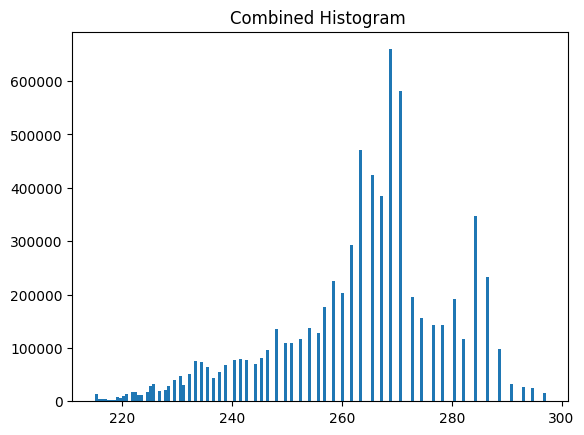

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(bsfc_data, bins=150)
plt.title("Combined Histogram ")
plt.show()

In [ ]:
threshold = 253
percentage = (bsfc_data > threshold).mean() * 100

print(f"Percentage of values < {threshold}: {percentage:.2f}%")

Percentage of values < 253: 75.30%


In [ ]:
def idle_time_percentage(df, time_col, idle_col):
    dt = df[time_col].diff().shift(-1).fillna(0)
    return 100 * (dt * df[idle_col]).sum() / dt.sum()

In [ ]:
IDLE_RPM_MIN = 0
IDLE_RPM_MAX = 1000
IDLE_TORQUE_MAX = 10  # Nm (adjust to your engine)

# -----------------------------
# Identify idle points
# -----------------------------
port_side["is_idle"] = (
    (port_side["rpm"] >= IDLE_RPM_MIN) &
    (port_side["rpm"] <= IDLE_RPM_MAX) &
    (port_side["torque_nm"].abs() <= IDLE_TORQUE_MAX)
)

# -----------------------------
# Time weighting
# -----------------------------
# Compute delta time between samples
port_side["dt"] = port_side["datetime"].diff().dt.total_seconds()

# Replace NaN (first row) with 0
port_side["dt"] = port_side["dt"].fillna(0)

total_time = port_side["dt"].sum()
idle_time = port_side.loc[port_side["is_idle"], "dt"].sum()

idle_percentage = 100 * idle_time / total_time

print(f"Idle time percentage: {idle_percentage:.2f}%")

Idle time percentage: 0.27%


In [ ]:
IDLE_RPM_MIN = 0
IDLE_RPM_MAX = 1000
IDLE_TORQUE_MAX = 10  # Nm (adjust to your engine)

# -----------------------------
# Identify idle points
# -----------------------------
stbd_side["is_idle"] = (
    (stbd_side["rpm"] >= IDLE_RPM_MIN) &
    (stbd_side["rpm"] <= IDLE_RPM_MAX) &
    (stbd_side["torque_nm"].abs() <= IDLE_TORQUE_MAX)
)

# -----------------------------
# Time weighting
# -----------------------------
# Compute delta time between samples
stbd_side["dt"] = stbd_side["datetime"].diff().dt.total_seconds()

# Replace NaN (first row) with 0
stbd_side["dt"] = stbd_side["dt"].fillna(0)

total_time = stbd_side["dt"].sum()
idle_time = stbd_side.loc[stbd_side["is_idle"], "dt"].sum()

idle_percentage = 100 * idle_time / total_time

print(f"Idle time percentage: {idle_percentage:.2f}%")

Idle time percentage: 1.56%


In [ ]:
port_side['dt'] = port_side['datetime'].diff().shift(-1).dt.total_seconds().fillna(0)
BSFC_THRESHOLD = 260  # g/kWh, adjust to your engine
port_side['engine_efficient'] = port_side['bsfc'] < BSFC_THRESHOLD

# Compute energy contributions
E_engine = (port_side.loc[port_side['engine_efficient'], 'power_kw'] * port_side.loc[port_side['engine_efficient'], 'dt']).sum()
E_batt = (port_side.loc[~port_side['engine_efficient'], 'power_kw'] * port_side.loc[~port_side['engine_efficient'], 'dt']).sum()

battery_fraction = E_batt / (E_batt + E_engine)
print(f"Battery needs to supply ~{battery_fraction*100:.1f}% of total energy")

Battery needs to supply ~26.8% of total energy


In [ ]:
stbd_side['dt'] = stbd_side['datetime'].diff().shift(-1).dt.total_seconds().fillna(0)
BSFC_THRESHOLD = 253  # g/kWh, adjust to your engine
stbd_side['engine_efficient'] = stbd_side['bsfc'] < BSFC_THRESHOLD

# Compute energy contributions
E_engine = (stbd_side.loc[stbd_side['engine_efficient'], 'power_kw'] * stbd_side.loc[stbd_side['engine_efficient'], 'dt']).sum()
E_batt = (stbd_side.loc[~stbd_side['engine_efficient'], 'power_kw'] * stbd_side.loc[~stbd_side['engine_efficient'], 'dt']).sum()

battery_fraction = E_batt / (E_batt + E_engine)
print(f"Battery needs to supply ~{battery_fraction*100:.1f}% of total energy")

Battery needs to supply ~34.1% of total energy
